# Sharp Boundary Inversion (SBI) for TEM

This notebook adapts Ishizu and Fukahata's (2026) Sharp Boundary Inversion from 1-D magnetotellurics to 1-D TEM. SBI is not a global blocky or L1 inversion. It keeps ordinary L2 smoothing over most of the model and relaxes smoothing only at a small number of data-supported interfaces.

## The main idea in plain language

A conventional inversion asks: **which resistivity in every thin numerical cell gives a smooth model that fits the TEM data?** SBI adds a structural question: **at which few interfaces should that smoothness rule be relaxed?**

The workflow is:

1. Fit a conventional smooth model on a fine, fixed numerical mesh.
2. Reuse its response and Jacobian to cheaply screen candidate boundary sets with quasi-linearized ABIC.
3. Test structures with zero, one, two, and three sharp boundaries.
4. For every tested structure, refit all resistivities and choose its best global smoothing strength $\lambda$.
5. Select the boundary count with the lowest complexity-penalized ABIC.

There are three nested levels:

- **Screening:** forward-select separated interfaces by jointly evaluating their quasi-linearized ABIC; this defines broad search windows without using the true model.
- **Inner loop:** Gauss-Newton updates all log10 resistivities; a scalar search selects $\lambda$ by minimizing quasi-linearized ABIC.
- **Outer loop:** Optuna searches boundary indices $z_b$ and local relaxation parameters $v_b$ for a fixed boundary count $N_b$.
- **Model selection:** penalized ABIC compares the best results for $N_b=0,1,2,3$.

The true model is used only to generate and assess this synthetic example. It is not supplied to the inversion or boundary search.

Reference: Ishizu, K. and Fukahata, Y. (2026), *Earth, Planets and Space*, 78:153, https://doi.org/10.1186/s40623-026-02493-w.

In [2]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import optuna
from scipy.linalg import eigh, solve
from scipy.optimize import minimize_scalar

project_root = Path.cwd()
if not (project_root / "pytem").is_dir():
    project_root = project_root.parent
if not (project_root / "pytem").is_dir():
    raise FileNotFoundError("Could not locate the pyTEM repository root.")
sys.path.insert(0, str(project_root))

from pytem import HAS_CUDA, HAS_NUMBA, fwd_circle_central, getJ_ana

USE_NUMBA = HAS_NUMBA
USE_CUDA = HAS_CUDA
print(f"Python: {sys.executable}")
print(f"Backends: Numba={USE_NUMBA}, CUDA={USE_CUDA}")
if sys.version_info[:2] != (3, 11):
    print("NOTE: this project is fastest and validated with the WinPython 3.11 kernel.")
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams.update({"figure.figsize": (8, 4.5), "font.size": 11})

Python: c:\WPy64-31180\python-3.11.8.amd64\python.exe
Backends: Numba=True, CUDA=True


## 1. Synthetic model and TEM observations

We use a **depth-scaled version of Case 1** from the paper: $100$, $10$, and $1000\ \Omega\mathrm{m}$ geological units separated by exact synthetic boundaries at 50 and 100 m.

### Supply the inversion thicknesses

The next cell is the single source of truth for the inversion mesh. `thicknesses` must contain one positive thickness for every finite inversion layer. The inversion automatically uses

$$N_m=\operatorname{len}(\mathtt{thicknesses})+1$$

resistivity parameters, because the final parameter is the half-space below the deepest finite interface. The included example creates 29 geometrically growing finite layers from 1 m near the surface to a total finite depth of 120 m. You can replace that construction with any one-dimensional positive array. Do not include a half-space thickness.

After changing the array, run the notebook from the mesh cell downward so `n_layers`, `m0`, cached responses, search depths, and plots are rebuilt consistently.

### Numerical cells are not geological layers

The numerical mesh does **not** prescribe the number of geological units. It only supplies enough resistivity parameters to represent smooth variations or sharp jumps. If ABIC selects $N_b$ boundaries, the inferred number of geological units is approximately $N_b+1$.

The synthetic forward model uses its own exact three-layer geometry. The inversion receives only the noisy TEM observations and represents them on the user-supplied mesh, so the true 50 and 100 m contacts are not silently snapped to inversion interfaces.

### TEM data and noise

The inversion uses log-amplitude data,

$$m_j=\log_{10}\rho_j,\qquad d_i=\log_{10}[-dB/dt(t_i)].$$

Noise is generated additively in linear TEM amplitude. Its standard deviation combines a relative component with a power-law absolute floor:

$$e_i=\max\left(f\,|d_i^{true}|,\;b\,t_i^{-1/2}\right),$$

$$d_i^{obs}=d_i^{true}+e_i\varepsilon_i,\qquad \varepsilon_i\sim\mathcal N(0,1).$$

The example uses $f=0.005$ and $b=10^{-12}$. Because the inversion takes a logarithm, Gaussian draws at or below zero are excluded and reported. Linear uncertainty for retained gates is propagated into log10 space as

$$\sigma_{\log_{10}d,i}\approx\frac{e_i}{d_i^{obs}\ln(10)}.$$

A 25 m transmitter radius and initial gates from $10^{-5}$ to $10^{-2}$ s emphasize sensitivity across the shallow target interval.

In [3]:
from scipy.optimize import root_scalar

def get_thicknesses(n_finite_layers, h0, total_depth):
    """Return geometrically growing finite-layer thicknesses."""
    if n_finite_layers < 1:
        raise ValueError("n_finite_layers must be at least 1.")
    if h0 <= 0.0 or total_depth <= 0.0:
        raise ValueError("h0 and total_depth must be positive.")
    if n_finite_layers * h0 > total_depth:
        raise ValueError("total_depth is too small for the requested first layer.")
    if np.isclose(n_finite_layers * h0, total_depth):
        return np.full(n_finite_layers, h0)

    def objective(growth):
        return h0 * (growth**n_finite_layers - 1.0) / (growth - 1.0) - total_depth

    growth = root_scalar(objective, bracket=(1.0 + 1e-10, 5.0), method="brentq").root
    return h0 * growth ** np.arange(n_finite_layers)


# User-supplied inversion mesh: edit this block to use another thickness array.
n_layers = 30
thicknesses = get_thicknesses(
    n_finite_layers=n_layers - 1,
    h0=1.0,
    total_depth=120.0,
)
n_layers = thicknesses.size + 1
interface_depths = np.cumsum(thicknesses)

# Exact synthetic earth, independent of the inversion discretization.
thicknesses_true = np.array([20.0, 20.0, 50.0])
resistivities_true = np.array([10.0, 100.0, 50.0, 1000.0])
boundary_depths_true = np.cumsum(thicknesses_true)

# TEM acquisition adapted to the shallow target interval.
tx_radius = 25.0
times = np.logspace(-5, -2, 40)

response_true = -fwd_circle_central(
    thicknesses=thicknesses_true,
    resistivities=resistivities_true,
    tx_radius=tx_radius,
    times=times,
    use_numba=USE_NUMBA,
    use_cuda=USE_CUDA,
    transform="dlf",
)

rng = np.random.default_rng(42)

# Combined relative Gaussian noise and power-law absolute noise floor.
b_noise = 1e-12
noise_frac = 0.005
noise_floor = b_noise * times ** (-0.5)
noise_std = np.maximum(noise_frac * np.abs(response_true), noise_floor)
response_obs = response_true + rng.normal(0.0, noise_std)

# Log-amplitude inversion cannot use nonpositive noisy amplitudes.
valid_gate = response_obs > 0.0
excluded_gates = np.count_nonzero(~valid_gate)
times = times[valid_gate]
response_true = response_true[valid_gate]
response_obs = response_obs[valid_gate]
noise_floor = noise_floor[valid_gate]
noise_std = noise_std[valid_gate]

# Propagate linear-amplitude uncertainty into log10 data space.
d_obs = np.log10(response_obs)
sigma_log10 = noise_std / (response_obs * np.log(10.0))
m0 = np.full(n_layers, np.log10(100.0))

print("True boundary depths [m]:", boundary_depths_true)
print("Inversion finite-layer thicknesses [m]:", np.round(thicknesses, 3))
print("Number of inversion parameters:", n_layers)
print("Deepest inversion interface [m]:", interface_depths[-1])
print(f"Relative noise: {100.0 * noise_frac:.2f}%")
print(f"Power-law coefficient b: {b_noise:.1e}")
print(f"Excluded nonpositive gates: {excluded_gates}")
print(f"Retained gates: {times.size}")
print(f"Floor-controlled retained gates: {np.count_nonzero(noise_floor >= noise_frac * np.abs(response_true))}")

True boundary depths [m]: [20. 40. 90.]
Inversion finite-layer thicknesses [m]: [ 1.     1.088  1.184  1.288  1.402  1.525  1.66   1.806  1.965  2.138
  2.326  2.531  2.754  2.997  3.261  3.548  3.861  4.201  4.571  4.974
  5.412  5.889  6.408  6.973  7.587  8.255  8.983  9.774 10.635]
Number of inversion parameters: 30
Deepest inversion interface [m]: 119.99999999999609
Relative noise: 0.50%
Power-law coefficient b: 1.0e-12
Excluded nonpositive gates: 2
Retained gates: 38
Floor-controlled retained gates: 12


## 2. From smooth inversion to a sharp boundary

### Ordinary smooth inversion

The first-difference matrix $R$ measures changes between neighboring log-resistivities:

$$R_i m=m_{i+1}-m_i,\qquad S_m=\|Rm\|_2^2.$$

For example, neighboring cells of $100$ and $10\ \Omega\mathrm{m}$ have a log10 difference of $-1$. Squaring and summing these differences makes large jumps expensive.

For a fixed global smoothing parameter $\lambda$, the objective is

$$U(m)=\underbrace{\|W_d[d-F(m)]\|_2^2}_{\text{data misfit}}+\underbrace{\lambda\|Rm\|_2^2}_{\text{model roughness}}.$$

- Small $\lambda$: prioritize fitting the data, allowing more structure.
- Large $\lambda$: prioritize a smooth model.
- $W_d$: divides each residual by its assumed standard deviation, so accurately known data carry more weight.

### What SBI changes

At a candidate boundary $j$, SBI scales only row $j$ of the difference matrix:

$$R_{j,j}=-v_b,\qquad R_{j,j+1}=v_b,\qquad 0<v_b\leq1.$$

That interface contributes $v_b^2(m_{j+1}-m_j)^2$ to roughness:

- $v_b=1$: ordinary smoothing.
- $v_b=0.1$: only 1% of the ordinary squared jump penalty.
- $v_b\rightarrow0$: a sharp jump is almost unpenalized.

All unselected interfaces keep $v_b=1$. SBI can therefore preserve smooth structure away from a few boundaries, unlike a global blocky inversion.

### One Gauss-Newton iteration

At iteration $k$, the nonlinear forward model is linearized with Jacobian $J_k$:

$$[J_k^T W_d^T W_dJ_k+\lambda R^TR]\,\Delta m=J_k^TW_d^TW_d[d-F(m_k)]-\lambda R^TRm_k.$$

$J_{ij}$ describes how log-data gate $i$ changes when log-resistivity cell $j$ changes. For each candidate $\lambda$, this system balances the update requested by the data against the update allowed by smoothing.

After selecting $\lambda$, the model is updated and pyTEM recomputes the nonlinear response and analytical Jacobian. Each update is capped at one decade in resistivity to prevent overshoot. The inner loop stops when ABIC changes by at most 0.1.

In [4]:
SBI_ENGINE_VERSION = "linearized-abic-v2"

_tem_cache = {}

print(f"SBI engine: {SBI_ENGINE_VERSION}")



def tem_response_and_jacobian(m):

    """Return log10(-dB/dt) and dlog10(data)/dlog10(rho)."""

    key = np.asarray(m, dtype=float).tobytes()

    if key in _tem_cache:

        return _tem_cache[key]

    response = -fwd_circle_central(

        thicknesses, 10.0**m, tx_radius, times,

        use_numba=USE_NUMBA, use_cuda=USE_CUDA, transform="dlf",

    )

    if np.any(response <= 0.0):

        raise ValueError("TEM response must be positive after applying the step-off sign.")



    # getJ_ana expects natural-log resistivity. The derivative is unchanged

    # when both data and model are converted from natural log to log10.

    J = getJ_ana(

        thicknesses, m * np.log(10.0), tx_radius, times,

        use_numba=USE_NUMBA, use_cuda=USE_CUDA, transform="dlf",

    )

    result = (np.log10(response), J)

    _tem_cache[key] = result

    return result





def build_sbi_R(n_parameters, boundary_indices=(), boundary_variances=()):

    """Paper Eq. 3: scale only selected first-difference rows by vb."""

    R = np.zeros((n_parameters, n_parameters))

    for index in range(n_parameters - 1):

        R[index, index:index + 2] = (-1.0, 1.0)

    for index, variance in zip(boundary_indices, boundary_variances):

        R[index] *= variance

    return R





def regularization_spectrum(R):

    RtR = R.T @ R

    eigenvalues = eigh(RtR, eigvals_only=True)

    positive = eigenvalues[eigenvalues > 1e-15]

    return RtR, positive.size, np.log(positive).sum()





def evaluate_abic_step(log10_lambda, m, residual, J, R, RtR, rank_R, log_pdet_RtR, max_dm=1.0):

    """Quasi-linearized ABIC from Eq. 9 and the released SBI engine."""

    smoothing = 10.0**log10_lambda

    Jw = J / sigma_log10[:, None]

    rw = residual / sigma_log10

    lhs = Jw.T @ Jw + smoothing * RtR

    rhs = Jw.T @ rw - smoothing * RtR @ m

    try:

        dm = solve(lhs, rhs, assume_a="pos")

    except np.linalg.LinAlgError:

        return np.inf, None, np.inf



    largest_update = np.max(np.abs(dm))

    if largest_update > max_dm:

        dm *= max_dm / largest_update



    m_new = m + dm

    # ABIC_QL evaluates the Gauss-Newton linearization (paper Eqs. 4 and 9).

    # Reusing J here avoids a full TEM forward/Jacobian call for every

    # candidate lambda tested by Brent's method.

    residual_new = residual - J @ dm

    weighted_ss = np.sum((residual_new / sigma_log10)**2)

    U = weighted_ss + smoothing * np.sum((R @ m_new)**2)

    scale = U / d_obs.size

    if scale <= 0.0:

        return np.inf, None, np.inf



    lhs_eigenvalues = eigh(lhs, eigvals_only=True)

    if np.any(lhs_eigenvalues <= 1e-15):

        return np.inf, None, np.inf

    log_det_lhs = np.log(lhs_eigenvalues).sum()

    log_det_regularization = rank_R * np.log(smoothing) + log_pdet_RtR

    abic = d_obs.size * np.log(2.0 * np.pi * scale) + log_det_lhs - log_det_regularization + d_obs.size

    rms = np.sqrt(weighted_ss / d_obs.size)

    return abic, dm, rms





def apply_valid_model_update(m, dm, max_backtracks=12):

    """Backtrack until the nonlinear response is valid in log-amplitude space."""

    step_scale = 1.0

    for _ in range(max_backtracks + 1):

        candidate = m + step_scale * dm

        try:

            tem_response_and_jacobian(candidate)

        except ValueError as error:

            if "must be positive" not in str(error):

                raise

            step_scale *= 0.5

            continue

        return candidate, step_scale

    return None, 0.0





def run_inner_inversion(boundary_indices=(), boundary_variances=(), initial_model=None, max_iterations=12, verbose=False):

    """GN model updates with a Brent search for lambda at every iteration."""

    m = m0.copy() if initial_model is None else np.asarray(initial_model).copy()

    R = build_sbi_R(n_layers, boundary_indices, boundary_variances)

    RtR, rank_R, log_pdet_RtR = regularization_spectrum(R)

    previous_abic = np.inf

    history = []



    for iteration in range(max_iterations):

        predicted, J = tem_response_and_jacobian(m)

        residual = d_obs - predicted



        def target(log10_lambda):

            value, _, _ = evaluate_abic_step(

                log10_lambda, m, residual, J, R, RtR, rank_R, log_pdet_RtR

            )

            return value if np.isfinite(value) else 1e100



        search = minimize_scalar(

            target, bounds=(-3.0, 7.0), method="bounded", options={"xatol": 1e-3}

        )

        log10_lambda = search.x

        abic, dm, rms = evaluate_abic_step(

            log10_lambda, m, residual, J, R, RtR, rank_R, log_pdet_RtR

        )

        if dm is None:

            break



        m_new, step_scale = apply_valid_model_update(m, dm)

        if m_new is None:

            if verbose:

                print(f"GN {iteration:2d}: no positive-response update found; stopping.")

            break

        m = m_new

        history.append((iteration, rms, abic, 10.0**log10_lambda))

        if verbose:

            scale_note = "" if step_scale == 1.0 else f", step={step_scale:.3f}"

            print(

                f"GN {iteration:2d}: RMS={rms:6.3f}, ABIC={abic:8.2f}, "

                f"lambda={10.0**log10_lambda:.2e}{scale_note}"

            )

        if np.isfinite(previous_abic) and abs(previous_abic - abic) <= 0.1:

            break

        previous_abic = abic



    if not history:

        predicted, _ = tem_response_and_jacobian(m)

        rms = np.sqrt(np.mean(((d_obs - predicted) / sigma_log10)**2))

        return {

            "m": m,

            "rho": 10.0**m,

            "abic_raw": np.inf,

            "rms": rms,

            "lambda": np.nan,

            "history": history,

        }



    final_abic, final_rms, final_lambda = history[-1][2], history[-1][1], history[-1][3]

    return {

        "m": m,

        "rho": 10.0**m,

        "abic_raw": final_abic,

        "rms": final_rms,

        "lambda": final_lambda,

        "history": history,

    }

SBI engine: linearized-abic-v2


## 3. What ABIC measures

A low RMS alone cannot establish whether a sharp boundary is required. Smooth and sharp models can often fit the same TEM data almost equally well. ABIC asks a broader question:

> After accounting for uncertainty and model flexibility, which structural model gives the most plausible explanation of the observations?

Akaike's Bayesian Information Criterion approximates negative log marginal likelihood. Lower ABIC is better. Marginal likelihood favors structures that explain the data over a useful volume of possible model values, rather than structures that fit only after very specific tuning.

For each Gauss-Newton linearization, the notebook evaluates the paper's quasi-linearized form, up to constants shared by all candidates:

$$\mathrm{ABIC}_{QL}=N\log U(m^*)-\log|\lambda R^TR|_+ +\log|J^TW_d^TW_dJ+\lambda R^TR|+2N_P+Q.$$

### Meaning of the terms

- $N\log U(m^*)$: measures the achieved combination of weighted data misfit and regularization penalty.
- $-\log|\lambda R^TR|_+$: accounts for the volume implied by the smoothness prior.
- $+\log|J^TW_d^TW_dJ+\lambda R^TR|$: accounts for how strongly the data and prior together constrain the model.
- $+2N_P$: penalizes structural complexity.
- $Q$: a constant shared by candidates fitted to the same dataset, so it does not affect their ranking.

One boundary contributes two structural hyperparameters: its index $z_b$ and relaxation $v_b$. Therefore

$$N_P=2N_b,\qquad 2N_P=4N_b.$$

This penalty is why adding boundaries does not automatically improve the selected model.

### Why a pseudo-determinant appears

First differences do not constrain a constant shift of the whole model, so $R^TR$ has one zero eigenvalue. The pseudo-determinant $|\cdot|_+$ multiplies only positive eigenvalues. In code, determinant terms are evaluated as sums of logarithms of positive eigenvalues, which is numerically more stable than multiplying them directly.

### How to compare scores

Only differences between candidates using the same TEM data, errors, and numerical mesh are meaningful. If $A_{min}$ is the smallest score, define

$$\Delta\mathrm{ABIC}=A-A_{min}.$$

- $\Delta\mathrm{ABIC}\leq2$: candidates are statistically difficult to distinguish.
- Clearly larger $\Delta\mathrm{ABIC}$: less support for that candidate.

RMS is still a useful fit diagnostic. RMS near 1 means residuals are roughly the size of the assumed noise. RMS below 1 can indicate a better-than-expected fit or conservative errors, but it does not by itself prove the geological structure is correct.

## 4. Two-stage SBI search

### Why nested loops are needed

Resistivities are continuous model parameters, while boundary indices are discrete structural choices. A single Gauss-Newton system cannot conveniently optimize both. The algorithm separates them:

- **Screening:** cheaply rank joint boundary sets with the converged smooth-model response and Jacobian.
- **Inner loop:** hold $N_b$, $z_b$, and $v_b$ fixed; search $\lambda$ and update all inversion-mesh resistivities.
- **Outer loop:** Optuna searches boundary indices $z_b$ and local relaxation parameters $v_b$ for a fixed boundary count $N_b$.
- **Model-selection loop:** compare the best complexity-penalized result for each $N_b$.

### Detailed workflow

1. Run a conventional smooth inversion, equivalent to $N_b=0$.
2. Reuse its converged response and Jacobian to score every possible first boundary with quasi-linearized ABIC.
3. Add further boundaries one at a time, scoring each new interface jointly with already selected interfaces.
4. Use neighborhoods around the joint-ABIC seeds as efficient boundary search windows for $N_b=1,2,3$.
5. Guarantee nonlinear trials at each seed and its immediate neighboring interfaces, then let Optuna spend the remaining trial budget.
6. For every trial, fix the proposed boundary indices and $v_b$ values, then fully refit all resistivity parameters.
7. For each boundary count, retain the smallest raw ABIC and add $4N_b$.
8. Select the $N_b$ with the smallest penalized ABIC.

Screening does not force boundaries into the result. It only decides where the expensive nonlinear search starts. ABIC can reject a boundary count, move a boundary within its window, or make a proposed boundary ineffective by selecting $v_b$ near 1.

### Why joint screening matters

One contact may be weak when tested alone because its TEM signature overlaps that of another contact. Ranking each interface independently can then miss a real boundary and exclude it from the search. Forward selection instead asks: **which additional interface most improves ABIC given the interfaces already selected?**

### Pseudocode

```text
smooth = invert with Nb = 0
seeds = forward-select separated interfaces by joint ABIC
score[0] = smooth ABIC

for Nb in [1, 2, 3]:
    build windows around the first Nb joint seeds
    enqueue the seeds and their neighboring interfaces

    for each remaining Optuna proposal (zb, vb):
        repeat Gauss-Newton iterations:
            compute TEM response and Jacobian
            find lambda minimizing quasi-linearized ABIC
            update every log-resistivity
        return converged raw ABIC

    score[Nb] = best raw ABIC + 4*Nb

select Nb with the smallest score
geological unit count = Nb + 1
```

The trial budgets below are deliberately small. For field interpretation, use larger budgets, test a defensible range of $N_b$, and calculate boundary uncertainty rather than reporting only one best inversion interface.

In [5]:
# Stage 1: conventional smooth inversion, equivalent to Nb = 0
smooth = run_inner_inversion(verbose=True)
smooth["abic_penalized"] = smooth["abic_raw"]
smooth["boundary_indices"] = []
smooth["boundary_variances"] = []

# Screen boundary sets using the same quasi-linearized ABIC used by the
# inversion. This is cheap because every candidate reuses one smooth-model
# response and Jacobian. Joint forward selection can reveal contacts that are
# weak individually but informative when another contact is already present.
screen_predicted, screen_J = tem_response_and_jacobian(smooth["m"])
screen_residual = d_obs - screen_predicted


def screen_boundary_set(indices, variance=1e-3):
    variances = np.full(len(indices), variance)
    R = build_sbi_R(n_layers, indices, variances)
    RtR, rank_R, log_pdet_RtR = regularization_spectrum(R)

    def target(log10_lambda):
        value, _, _ = evaluate_abic_step(
            log10_lambda, smooth["m"], screen_residual, screen_J,
            R, RtR, rank_R, log_pdet_RtR,
        )
        return value if np.isfinite(value) else 1e100

    search = minimize_scalar(
        target, bounds=(-3.0, 7.0), method="bounded", options={"xatol": 1e-3}
    )
    return target(search.x)


max_boundary_count = 3
minimum_separation = 4
ranked_peak_indices = []
for _ in range(max_boundary_count):
    candidates = [
        index for index in range(n_layers - 1)
        if all(abs(index - selected) >= minimum_separation for selected in ranked_peak_indices)
    ]
    candidate_scores = [
        screen_boundary_set(sorted(ranked_peak_indices + [index]))
        for index in candidates
    ]
    ranked_peak_indices.append(candidates[int(np.argmin(candidate_scores))])

interface_depths = np.cumsum(thicknesses)
print(
    "Joint-ABIC seed depths [m]:",
    interface_depths[ranked_peak_indices],
)


def make_search_ranges(boundary_count, half_width=3):
    centers = sorted(ranked_peak_indices[:boundary_count])
    ranges = [
        [max(0, center - half_width), min(n_layers - 2, center + half_width)]
        for center in centers
    ]
    for index in range(len(ranges) - 1):
        split = (centers[index] + centers[index + 1]) // 2
        ranges[index][1] = min(ranges[index][1], split)
        ranges[index + 1][0] = max(ranges[index + 1][0], split + 1)
    return [tuple(item) for item in ranges]


def optimize_boundary_count(boundary_count, n_trials):
    search_ranges = make_search_ranges(boundary_count)
    centers = sorted(ranked_peak_indices[:boundary_count])
    trial_results = {}
    depth_ranges = [
        (interface_depths[low], interface_depths[high])
        for low, high in search_ranges
    ]
    print(f"\nNb={boundary_count}: depth search ranges {depth_ranges} m")

    def objective(trial):
        indices = [
            trial.suggest_int(f"boundary_{number}", low, high)
            for number, (low, high) in enumerate(search_ranges)
        ]
        variances = [
            trial.suggest_float(f"variance_{number}", 1e-4, 1.0, log=True)
            for number in range(boundary_count)
        ]
        result = run_inner_inversion(indices, variances, initial_model=smooth["m"])
        trial_results[trial.number] = result
        return result["abic_raw"]

    sampler = optuna.samplers.TPESampler(
        n_startup_trials=min(5, n_trials), seed=42 + boundary_count
    )
    study = optuna.create_study(direction="minimize", sampler=sampler)

    # Guarantee evaluation of the joint-ABIC seed and each one-cell neighbor.
    # This small deterministic polish is important on a discrete 5 m mesh.
    seed_indices = [centers.copy()]
    for number in range(boundary_count):
        low, high = search_ranges[number]
        for offset in (-1, 1):
            neighbor = centers.copy()
            neighbor[number] = int(np.clip(neighbor[number] + offset, low, high))
            if neighbor not in seed_indices:
                seed_indices.append(neighbor)
    for indices in seed_indices[:n_trials]:
        seed = {}
        for number, index in enumerate(indices):
            seed[f"boundary_{number}"] = index
            seed[f"variance_{number}"] = 1e-3
        study.enqueue_trial(seed)

    study.optimize(objective, n_trials=n_trials, n_jobs=1, show_progress_bar=True)
    result = trial_results[study.best_trial.number]
    result["boundary_indices"] = [
        study.best_params[f"boundary_{number}"] for number in range(boundary_count)
    ]
    result["boundary_variances"] = [
        study.best_params[f"variance_{number}"] for number in range(boundary_count)
    ]
    result["abic_penalized"] = result["abic_raw"] + 4 * boundary_count
    return result


trial_budget = {1: 4, 2: 8, 3: 8}
print(f"Running automatic Nb=0..{max_boundary_count} selection with {SBI_ENGINE_VERSION}.")
print("If Optuna reports more than 20 s/trial, restart the kernel and Run All.")
model_candidates = {0: smooth}
for boundary_count, n_trials in trial_budget.items():
    model_candidates[boundary_count] = optimize_boundary_count(boundary_count, n_trials)

selected_nb = min(
    model_candidates,
    key=lambda count: model_candidates[count]["abic_penalized"],
)
sbi = model_candidates[selected_nb]
best_indices = sbi["boundary_indices"]
best_variances = sbi["boundary_variances"]
best_depths = interface_depths[best_indices] if best_indices else np.array([])

best_penalized_abic = sbi["abic_penalized"]
print("\nPenalized ABIC by boundary count:")
for boundary_count, result in model_candidates.items():
    delta_abic = result["abic_penalized"] - best_penalized_abic
    print(
        f"  Nb={boundary_count}: ABIC={result['abic_penalized']:.2f}, "
        f"delta={delta_abic:.2f}, RMS={result['rms']:.3f}"
    )
print(f"Selected Nb={selected_nb}, corresponding to {selected_nb + 1} geological units.")
print("Selected boundary depths [m]:", best_depths)
print("Selected boundary variances vb:", np.round(best_variances, 5))

GN  0: RMS=22.715, ABIC=  396.54, lambda=4.65e+05
GN  1: RMS= 0.757, ABIC=  153.87, lambda=2.45e+01
GN  2: RMS= 0.806, ABIC=  153.03, lambda=1.29e+01
GN  3: RMS= 0.811, ABIC=  153.40, lambda=1.00e+01
GN  4: RMS= 0.815, ABIC=  153.28, lambda=1.03e+01
GN  5: RMS= 0.815, ABIC=  153.22, lambda=1.03e+01
Joint-ABIC seed depths [m]: [90.60792272 19.91385891 61.3847515 ]
Running automatic Nb=0..3 selection with linearized-abic-v2.
If Optuna reports more than 20 s/trial, restart the kernel and Run All.

Nb=1: depth search ranges [(67.7928603173116, 119.99999999999609)] m


  0%|          | 0/4 [00:00<?, ?it/s]


Nb=2: depth search ranges [(12.917886266657053, 28.92659640120156), (67.7928603173116, 119.99999999999609)] m


  0%|          | 0/8 [00:00<?, ?it/s]


Nb=3: depth search ranges [(12.917886266657053, 28.92659640120156), (45.10890814309587, 74.76553523669541), (82.35251556253493, 119.99999999999609)] m


  0%|          | 0/8 [00:00<?, ?it/s]


Penalized ABIC by boundary count:
  Nb=0: ABIC=153.22, delta=8.74, RMS=0.815
  Nb=1: ABIC=161.90, delta=17.42, RMS=0.808
  Nb=2: ABIC=149.34, delta=4.86, RMS=0.928
  Nb=3: ABIC=144.48, delta=0.00, RMS=0.801
Selected Nb=3, corresponding to 4 geological units.
Selected boundary depths [m]: [19.91385891 61.3847515  82.35251556]
Selected boundary variances vb: [0.001 0.001 0.001]


## 5. How to read the search output

The preceding cell first prints the smooth Gauss-Newton iterations, then the joint-ABIC seed depths and search ranges, and finally the model-selection table.

### Smooth inversion iterations

A line such as

```text
GN  3: RMS=0.770, ABIC=148.75, lambda=6.75e+00
```

reports the noise-normalized RMS, quasi-linearized ABIC, and selected global smoothing strength after one Gauss-Newton update. These are iterations of one inversion, not different geological models.

### Joint-ABIC seeds

The seed depths are taken from `np.cumsum(thicknesses)`. The first is the best one-boundary candidate. Each later seed is the interface that contributes most when considered jointly with the seeds already selected. A seed is only a starting point: deterministic neighboring trials and Optuna can move it within its search window.

### Final model-selection table

For each $N_b$, the table reports:

- **ABIC:** raw ABIC plus the $4N_b$ structural-complexity penalty.
- **delta:** difference from the lowest penalized ABIC in the table.
- **RMS:** noise-normalized data residual of that candidate.

The candidate with `delta=0` is selected. Candidates with $\Delta\mathrm{ABIC}\leq2$ should be treated as statistically difficult to distinguish rather than declaring one layer count certain.

### Selected boundary parameters

- **Boundary depth:** the depth of the selected inversion-mesh interface.
- **$v_b$ near 1:** interface remains effectively smooth.
- **Small $v_b$:** smoothing is strongly relaxed and the recovered model may jump there.
- **$\lambda$:** controls background smoothing everywhere, including non-boundary interfaces.

Depth precision is controlled by the local spacing of the supplied mesh. On a graded mesh, shallow contacts can be localized more finely than deep contacts.

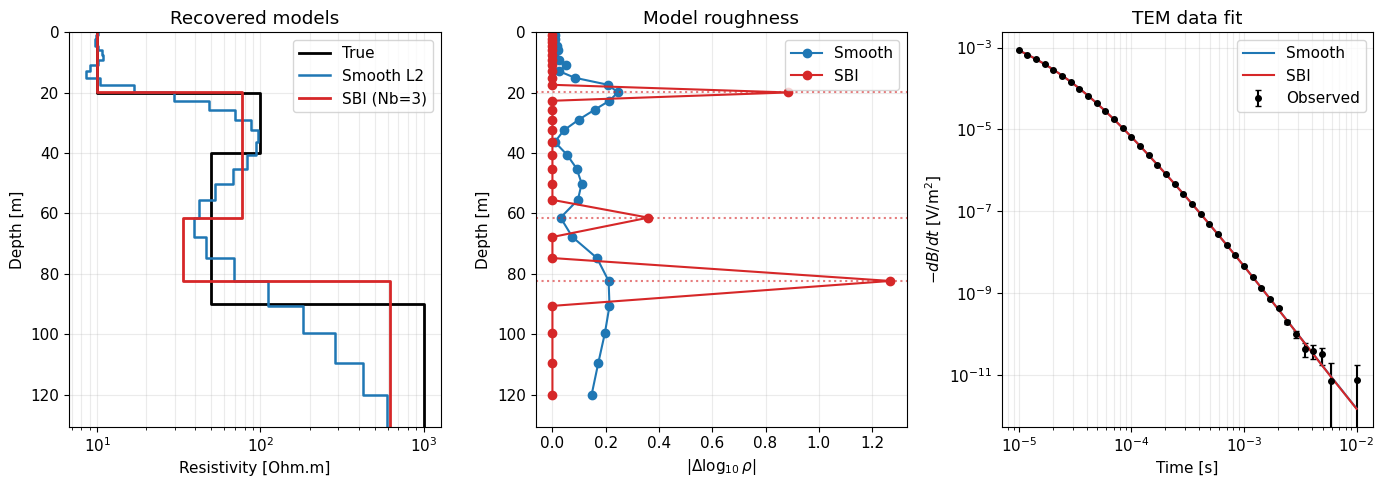

In [6]:
def step_coordinates(values, finite_thicknesses, plot_bottom=None):
    tops = np.r_[0.0, np.cumsum(finite_thicknesses)]
    bottom = tops[-1] + finite_thicknesses[-1] if plot_bottom is None else plot_bottom
    return np.repeat(values, 2), np.r_[0.0, np.repeat(tops[1:], 2), bottom]


fig, axes = plt.subplots(1, 3, figsize=(14, 5))
plot_depth = interface_depths[-1] + thicknesses[-1]

x, z = step_coordinates(resistivities_true, thicknesses_true, plot_bottom=plot_depth)
axes[0].plot(x, z, color="black", label="True", linewidth=2.0)
for values, color, label, width in [
    (smooth["rho"], "tab:blue", "Smooth L2", 1.8),
    (sbi["rho"], "tab:red", f"SBI (Nb={selected_nb})", 2.0),
]:
    x, z = step_coordinates(values, thicknesses, plot_bottom=plot_depth)
    axes[0].plot(x, z, color=color, label=label, linewidth=width)
axes[0].set(
    xscale="log", xlabel="Resistivity [Ohm.m]", ylabel="Depth [m]",
    title="Recovered models", ylim=(plot_depth, 0),
)
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend()

axes[1].plot(np.abs(np.diff(smooth["m"])), interface_depths, "o-", color="tab:blue", label="Smooth")
axes[1].plot(np.abs(np.diff(sbi["m"])), interface_depths, "o-", color="tab:red", label="SBI")
for depth in best_depths:
    axes[1].axhline(depth, color="tab:red", linestyle=":", alpha=0.6)
axes[1].set(
    xlabel=r"$|\Delta \log_{10} \rho|$", ylabel="Depth [m]",
    title="Model roughness", ylim=(plot_depth, 0),
)
axes[1].grid(True, alpha=0.25)
axes[1].legend()

predicted_smooth, _ = tem_response_and_jacobian(smooth["m"])
predicted_sbi, _ = tem_response_and_jacobian(sbi["m"])
axes[2].errorbar(
    times, response_obs, yerr=noise_std,
    fmt="o", color="black", markersize=4, capsize=2, label="Observed",
)
axes[2].plot(times, 10.0**predicted_smooth, color="tab:blue", label="Smooth")
axes[2].plot(times, 10.0**predicted_sbi, color="tab:red", label="SBI")
axes[2].set(
    xscale="log", yscale="log", xlabel="Time [s]",
    ylabel=r"$-dB/dt$ [V/m$^2$]", title="TEM data fit",
)
axes[2].grid(True, which="both", alpha=0.25)
axes[2].legend()

plt.tight_layout()
plt.show()

## Interpretation and limitations

A selected $v_b$ near one means the interface remains effectively smooth; a small value locally relaxes continuity and permits a jump. SBI should therefore preserve smooth structure away from selected boundaries, unlike global L1 sharpening.

The smooth and SBI inversions estimate the same `len(thicknesses) + 1` log-resistivities on the supplied mesh. The smooth inversion is not given the true boundary locations, and SBI changes only selected rows of the same first-difference operator.

A recovered boundary can only occur at an inversion-mesh interface. Its depth uncertainty therefore cannot be smaller than the local mesh spacing. A production assessment should use more trials and calculate the $\Delta\mathrm{ABIC}\leq2$ depth interval while re-optimizing $m$, $v_b$, and $\lambda$ at every tested depth.

This is an algorithmic TEM adaptation of the paper. TEM supplies one log-amplitude datum per gate rather than MT apparent resistivity and phase, so ABIC values must only be compared among models fitted to the same TEM dataset, error model, and numerical mesh.

For production use:

- choose a mesh that spans the data's investigation depth without excessive deep parameters,
- increase `n_trials` after inspecting the joint-ABIC search ranges,
- compare candidate boundary counts using `ABIC + 2N_P`,
- treat $\Delta\mathrm{ABIC}\leq2$ as statistically indistinguishable.

## Kenbec Transect 1: smooth and sharp inversions



This field-data section applies the same smooth/SBI engine to every sounding on Kenbec line 1. LM and HM are fitted jointly. The transmitter waveform and finite receiver gates are handled with the quintic B-spline matrix method from the Kenbec matrix notebook:



$$d_{gate}=M_{gate}d_{step},\qquad J_{gate}=M_{gate}J_{step}.$$



The LM/HM matrices are built once on a shared step-response time grid and reused for all Transect 1 soundings and all inversion iterations. `KENBEC_MAX_BOUNDARIES = 1` gives a practical smooth-versus-one-boundary comparison; increase it only when the additional runtime is acceptable.

In [13]:
import importlib

import time



from pytem import fwd_circle_offset, setup_waveform_matrix



offline_dir = project_root / "notebooks" / "offline_files"

if str(offline_dir) not in sys.path:

    sys.path.insert(0, str(offline_dir))

import read_kenbec_xyz as _kenbec_reader

importlib.reload(_kenbec_reader)

from read_kenbec_xyz import read_kenbec_xyz



KENBEC_XYZ = Path.home() / "Downloads" / "Kenbec" / "kenbec_project_StationData.xyz"

TRANSECT_LINE = "1"

MOMENTS = ("LM", "HM")

CURRENTS = {"LM": 1.0, "HM": 10.0}

MAX_NOISE = 0.50

NOISE_FLOOR_FRAC = 0.01



# Matrix-waveform accuracy controls. The matrices are built once and reused.

N_STEP = 300

N_DENSE_GATE = 400

N_KERNEL_PER_SEGMENT = 81

PAD_DECADES = 1.0



tem_kenbec = read_kenbec_xyz(str(KENBEC_XYZ))

line_values = tem_kenbec.data["Line"].astype(str).str.strip()

transect_station_indices = np.flatnonzero(line_values.to_numpy() == TRANSECT_LINE)

if transect_station_indices.size == 0:

    raise ValueError(f"No Kenbec stations found on line {TRANSECT_LINE!r}.")



# Convert longitude/latitude to local metric coordinates for distance along line.

transect_table = tem_kenbec.data.iloc[transect_station_indices].copy()

longitude = np.deg2rad(transect_table["Longitude"].to_numpy(float))

latitude = np.deg2rad(transect_table["Latitude"].to_numpy(float))

earth_radius = 6_371_000.0

local_x = earth_radius * np.cos(latitude.mean()) * (longitude - longitude[0])

local_y = earth_radius * (latitude - latitude[0])

transect_distance = np.r_[0.0, np.cumsum(np.hypot(np.diff(local_x), np.diff(local_y)))]



# Waveform, timing, and geometry are common to all stations.

reference_systems = {

    moment: tem_kenbec.to_pytem(

        moment, peak_current=CURRENTS[moment], station=int(transect_station_indices[0])

    )

    for moment in MOMENTS

}

tx_side = float(reference_systems["HM"]["tx_size"])

tx_radius = float(np.sqrt(tx_side**2 / np.pi))

rx_x = abs(float(reference_systems["HM"]["rx_x"]))

rx_y = abs(float(reference_systems["HM"]["rx_y"]))



delay_sets = []

for system in reference_systems.values():

    waveform_times = np.asarray(system["waveform_times"], dtype=float)

    waveform_currents = np.asarray(system["waveform_currents"], dtype=float)

    active = np.flatnonzero(np.diff(waveform_currents) != 0.0)

    endpoints = np.unique(np.r_[waveform_times[active], waveform_times[active + 1]])

    outputs = np.r_[system["times"], system["gate_open"], system["gate_close"]]

    delays = outputs[:, None] - endpoints[None, :]

    delay_sets.append(delays[delays > 0.0])



positive_delays = np.concatenate(delay_sets)

shared_t_step = np.logspace(

    np.log10(positive_delays.min()) - PAD_DECADES,

    np.log10(positive_delays.max()) + PAD_DECADES,

    N_STEP,

)



kenbec_matrices = {}

for moment, system in reference_systems.items():

    _, apply_gate = setup_waveform_matrix(

        system["times"],

        system["waveform_times"],

        system["waveform_currents"],

        gate_open=system["gate_open"],

        gate_close=system["gate_close"],

        t_step=shared_t_step,

        n_per_segment=N_KERNEL_PER_SEGMENT,

        n_dense_gate=N_DENSE_GATE,

    )

    kenbec_matrices[moment] = apply_gate.matrix



# Field inversion mesh. The final parameter is the half-space.

n_layers = 15

thicknesses = np.logspace(np.log10(2.0), np.log10(25.0), n_layers - 1)

interface_depths = np.cumsum(thicknesses)

m0 = np.full(n_layers, np.log10(100.0))



kenbec_fit_systems = []

_tem_cache = {}



def configure_kenbec_station(station_index):

    """Install one station's LM/HM data in the existing SBI engine."""

    global kenbec_fit_systems, d_obs, sigma_log10, _tem_cache

    kenbec_fit_systems = []

    for moment in MOMENTS:

        system = tem_kenbec.to_pytem(

            moment, peak_current=CURRENTS[moment], station=int(station_index)

        )

        observed = np.asarray(system["obs_data"], dtype=float)

        fractional_noise = np.asarray(system["noise_std"], dtype=float)

        noise_absolute = np.maximum(fractional_noise, NOISE_FLOOR_FRAC) * observed

        good = (

            np.isfinite(observed)

            & np.isfinite(noise_absolute)

            & (observed > 0.0)

            & (noise_absolute > 0.0)

            & (fractional_noise <= MAX_NOISE)

        )

        kenbec_fit_systems.append({

            "name": moment,

            "M": kenbec_matrices[moment][good],

            "times": np.asarray(system["times"])[good],

            "obs": observed[good],

            "noise_abs": noise_absolute[good],

        })



    observed_all = np.concatenate([item["obs"] for item in kenbec_fit_systems])

    noise_all = np.concatenate([item["noise_abs"] for item in kenbec_fit_systems])

    if observed_all.size < n_layers:

        raise ValueError(f"Station {station_index} has only {observed_all.size} usable gates.")

    d_obs = np.log10(observed_all)

    sigma_log10 = noise_all / (observed_all * np.log(10.0))

    _tem_cache = {}

    return observed_all.size



def tem_response_and_jacobian(m):

    """Matrix-waveform log10 gate response and log-log Jacobian."""

    key = np.asarray(m, dtype=float).tobytes()

    if key in _tem_cache:

        return _tem_cache[key]



    step_response = -fwd_circle_offset(

        thicknesses, 10.0**m, tx_radius, rx_x, shared_t_step,

        current=1.0, signal=-1, use_numba=USE_NUMBA, use_cuda=USE_CUDA,

        transform="dlf",

    )

    prediction = np.concatenate([

        item["M"] @ step_response for item in kenbec_fit_systems

    ])

    if np.any(prediction <= 0.0):

        raise ValueError("Matrix-waveform gate prediction must be positive.")



    step_jacobian = getJ_ana(

        thicknesses=thicknesses,

        log_resistivities=m * np.log(10.0),

        tx_size=tx_radius,

        times=shared_t_step,

        geometry="circle_offset",

        rx_x=rx_x,

        rx_y=rx_y,

        use_numba=USE_NUMBA,

        use_cuda=USE_CUDA,

        transform="dlf",

        jacobian_mode="absolute",

    )

    gate_jacobian = np.vstack([

        item["M"] @ step_jacobian for item in kenbec_fit_systems

    ])

    result = (np.log10(prediction), gate_jacobian / prediction[:, None])

    _tem_cache[key] = result

    return result



print(f"Kenbec Transect {TRANSECT_LINE}: {transect_station_indices.size} stations")

print(f"Distance: {transect_distance[0]:.1f} to {transect_distance[-1]:.1f} m")

print(f"Matrix waveform: shared t_step={shared_t_step.size}")

for moment in MOMENTS:

    print(f"  {moment}: M_gate={kenbec_matrices[moment].shape}")

Kenbec Transect 1: 24 stations
Distance: 0.0 to 300.0 m
Matrix waveform: shared t_step=300
  LM: M_gate=(6, 300)
  HM: M_gate=(22, 300)


In [15]:
RUN_KENBEC_TRANSECT = True

KENBEC_MAX_STATIONS = 2  # None runs all 24 Transect 1 stations
KENBEC_MAX_BOUNDARIES = 3
KENBEC_TRIAL_BUDGET = {1: 20, 2: 40, 3: 60}
KENBEC_SEARCH_HALF_WIDTH = 5

if not 0 <= KENBEC_MAX_BOUNDARIES <= 3:
    raise ValueError("KENBEC_MAX_BOUNDARIES must be between 0 and 3.")
if any(KENBEC_TRIAL_BUDGET.get(count, 0) < 1 for count in range(1, KENBEC_MAX_BOUNDARIES + 1)):
    raise ValueError("KENBEC_TRIAL_BUDGET must provide at least one trial per boundary count.")
if KENBEC_SEARCH_HALF_WIDTH < 1:
    raise ValueError("KENBEC_SEARCH_HALF_WIDTH must be positive.")


def make_search_ranges(boundary_count, half_width=None):
    """Build nonoverlapping field-search windows around joint-ABIC seeds."""
    if half_width is None:
        half_width = KENBEC_SEARCH_HALF_WIDTH
    centers = sorted(ranked_peak_indices[:boundary_count])
    ranges = [
        [max(0, center - half_width), min(n_layers - 2, center + half_width)]
        for center in centers
    ]
    for index in range(len(ranges) - 1):
        split = (centers[index] + centers[index + 1]) // 2
        ranges[index][1] = min(ranges[index][1], split)
        ranges[index + 1][0] = max(ranges[index + 1][0], split + 1)
    return [tuple(item) for item in ranges]


def fit_kenbec_station(station_index):
    """Run smooth and SBI model selection for one configured sounding."""
    global smooth, ranked_peak_indices, max_boundary_count

    usable_gates = configure_kenbec_station(station_index)
    smooth = run_inner_inversion(verbose=False)
    smooth["abic_penalized"] = smooth["abic_raw"]
    smooth["boundary_indices"] = []
    smooth["boundary_variances"] = []

    if KENBEC_MAX_BOUNDARIES == 0:
        return smooth, usable_gates

    screen_prediction, screen_jacobian = tem_response_and_jacobian(smooth["m"])
    screen_residual_local = d_obs - screen_prediction

    def score_boundary_set(indices, variance=1e-3):
        variances = np.full(len(indices), variance)
        regularization = build_sbi_R(n_layers, indices, variances)
        rtr, rank, log_pdet = regularization_spectrum(regularization)

        def target(log10_lambda):
            value, _, _ = evaluate_abic_step(
                log10_lambda, smooth["m"], screen_residual_local, screen_jacobian,
                regularization, rtr, rank, log_pdet,
            )
            return value if np.isfinite(value) else 1e100

        search = minimize_scalar(
            target, bounds=(-3.0, 7.0), method="bounded", options={"xatol": 1e-3}
        )
        return target(search.x)

    max_boundary_count = KENBEC_MAX_BOUNDARIES
    minimum_separation = 4
    ranked_peak_indices = []
    for _ in range(max_boundary_count):
        candidates = [
            index for index in range(n_layers - 1)
            if all(
                abs(index - selected) >= minimum_separation
                for selected in ranked_peak_indices
            )
        ]
        scores = [
            score_boundary_set(sorted(ranked_peak_indices + [index]))
            for index in candidates
        ]
        ranked_peak_indices.append(candidates[int(np.argmin(scores))])

    model_candidates_local = {0: smooth}
    for boundary_count in range(1, max_boundary_count + 1):
        model_candidates_local[boundary_count] = optimize_boundary_count(
            boundary_count, KENBEC_TRIAL_BUDGET[boundary_count]
        )
    selected_count = min(
        model_candidates_local,
        key=lambda count: model_candidates_local[count]["abic_penalized"],
    )
    return model_candidates_local[selected_count], usable_gates


station_indices_run = transect_station_indices.copy()
if KENBEC_MAX_STATIONS is not None:
    station_indices_run = station_indices_run[:max(0, int(KENBEC_MAX_STATIONS))]

kenbec_smooth_rho = np.full((station_indices_run.size, n_layers), np.nan)
kenbec_sbi_rho = np.full_like(kenbec_smooth_rho, np.nan)
kenbec_rms = np.full(station_indices_run.size, np.nan)
kenbec_selected_nb = np.full(station_indices_run.size, -1, dtype=int)
kenbec_boundary_depths = []
kenbec_results = []

if RUN_KENBEC_TRANSECT:
    total_trials = sum(
        KENBEC_TRIAL_BUDGET[count]
        for count in range(1, KENBEC_MAX_BOUNDARIES + 1)
    )
    print(
        f"Extensive SBI search: 1 smooth + {total_trials} sharp trials per sounding; "
        f"window half-width={KENBEC_SEARCH_HALF_WIDTH} interfaces."
    )
    started = time.perf_counter()
    for position, station_index in enumerate(station_indices_run):
        station_name = str(tem_kenbec.data.iloc[station_index]["Station"])
        print(
            f"\nTransect 1 sounding {position + 1}/{station_indices_run.size}: "
            f"row={station_index}, station={station_name}"
        )
        selected, usable_gates = fit_kenbec_station(int(station_index))
        kenbec_results.append(selected)
        kenbec_smooth_rho[position] = smooth["rho"]
        kenbec_sbi_rho[position] = selected["rho"]
        kenbec_rms[position] = selected["rms"]
        kenbec_selected_nb[position] = len(selected["boundary_indices"])
        depths = (
            interface_depths[selected["boundary_indices"]]
            if selected["boundary_indices"] else np.array([])
        )
        kenbec_boundary_depths.append(depths)
        print(
            f"  gates={usable_gates}, selected Nb={kenbec_selected_nb[position]}, "
            f"RMS={kenbec_rms[position]:.3f}, boundaries={np.round(depths, 1)} m"
        )

    elapsed = time.perf_counter() - started
    print(
        f"\nCompleted {station_indices_run.size} Transect 1 soundings "
        f"in {elapsed / 60.0:.1f} min."
    )
else:
    print("Set RUN_KENBEC_TRANSECT = True to run the Transect 1 inversions.")

Extensive SBI search: 1 smooth + 120 sharp trials per sounding; window half-width=5 interfaces.

Transect 1 sounding 1/2: row=0, station=1_00001

Nb=1: depth search ranges [(2.0, 20.594926001647714)] m


  0%|          | 0/20 [00:00<?, ?it/s]


Nb=2: depth search ranges [(2.0, 7.378640288547825), (10.960949547778826, 55.76022695681351)] m


  0%|          | 0/40 [00:00<?, ?it/s]


Nb=3: depth search ranges [(2.0, 7.378640288547825), (10.960949547778826, 44.26733734298777), (55.76022695681351, 132.2538289506554)] m


  0%|          | 0/60 [00:00<?, ?it/s]

[W 2026-08-17 20:21:06,674] Trial 31 failed with parameters: {'boundary_0': 0, 'boundary_1': 4, 'boundary_2': 13, 'variance_0': 0.0017662346057988384, 'variance_1': 0.00132535568661388, 'variance_2': 0.0002578968841717414} because of the following error: SystemError('CPUDispatcher(<function _tem_circular_grad_jit at 0x000002E4A79BC360>) returned a result with an exception set').
Traceback (most recent call last):
  File "c:\WPy64-31180\python-3.11.8.amd64\Lib\site-packages\numba\core\serialize.py", line 30, in _numba_unpickle
    def _numba_unpickle(address, bytedata, hashed):
    
KeyboardInterrupt

The above exception was the direct cause of the following exception:

SystemError: <function _numba_unpickle at 0x000002E4A7073BA0> returned a result with an exception set

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\WPy64-31180\python-3.11.8.amd64\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
 

SystemError: CPUDispatcher(<function _tem_circular_grad_jit at 0x000002E4A79BC360>) returned a result with an exception set

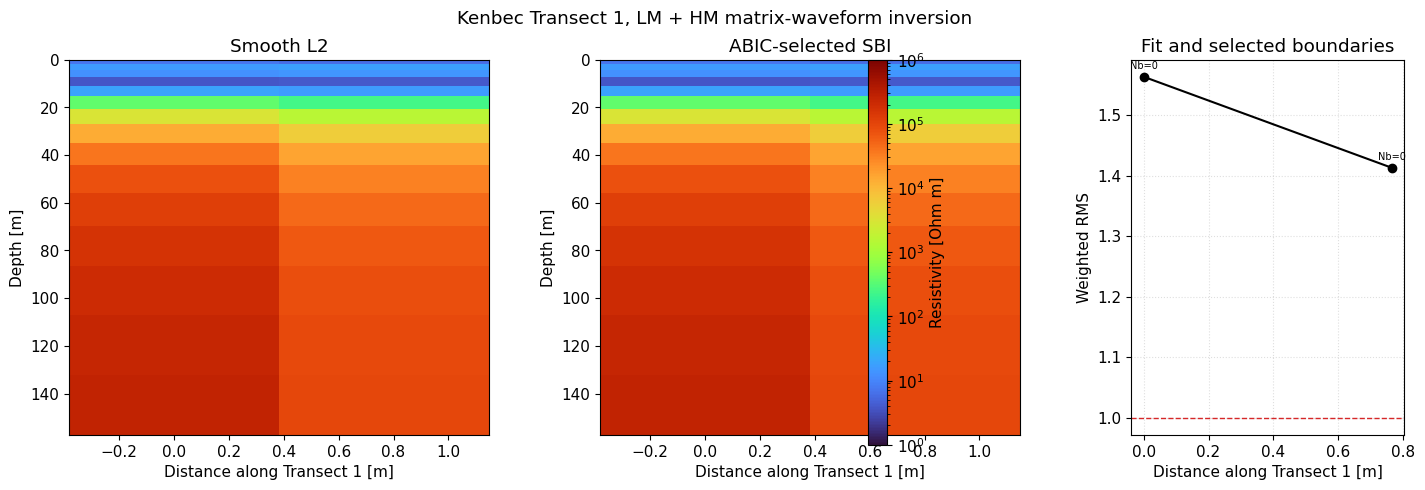

In [14]:
from matplotlib.colors import LogNorm



if RUN_KENBEC_TRANSECT and station_indices_run.size:

    distance_run = transect_distance[:station_indices_run.size]



    if distance_run.size == 1:

        x_edges = np.array([distance_run[0] - 0.5, distance_run[0] + 0.5])

    else:

        x_edges = np.r_[

            distance_run[0] - 0.5 * (distance_run[1] - distance_run[0]),

            0.5 * (distance_run[:-1] + distance_run[1:]),

            distance_run[-1] + 0.5 * (distance_run[-1] - distance_run[-2]),

        ]

    z_edges = np.r_[0.0, interface_depths, interface_depths[-1] + thicknesses[-1]]



    finite_rho = kenbec_sbi_rho[np.isfinite(kenbec_sbi_rho)]

    color_min = max(1.0, 10.0 ** np.floor(np.log10(np.nanpercentile(finite_rho, 2))))

    color_max = 10.0 ** np.ceil(np.log10(np.nanpercentile(finite_rho, 98)))

    if color_max <= color_min:

        color_max = 10.0 * color_min

    normalization = LogNorm(vmin=color_min, vmax=color_max)



    fig, axes = plt.subplots(

        1, 3, figsize=(15, 5), gridspec_kw={"width_ratios": [1.0, 1.0, 0.65]}

    )

    for axis, models, title in (

        (axes[0], kenbec_smooth_rho, "Smooth L2"),

        (axes[1], kenbec_sbi_rho, "ABIC-selected SBI"),

    ):

        image = axis.pcolormesh(

            x_edges, z_edges, models.T, shading="flat", cmap="turbo", norm=normalization

        )

        axis.set(

            xlabel="Distance along Transect 1 [m]",

            ylabel="Depth [m]",

            title=title,

            ylim=(z_edges[-1], 0.0),

        )



    for distance, depths in zip(distance_run, kenbec_boundary_depths):

        if len(depths):

            axes[1].scatter(

                np.full(len(depths), distance), depths,

                marker="_", s=90, linewidths=1.5, color="black",

            )



    colorbar = fig.colorbar(image, ax=axes[:2], pad=0.02)

    colorbar.set_label("Resistivity [Ohm m]")



    axes[2].plot(distance_run, kenbec_rms, "o-", color="black", label="RMS")

    axes[2].axhline(1.0, color="tab:red", linestyle="--", linewidth=1.0)

    axes[2].set(

        xlabel="Distance along Transect 1 [m]",

        ylabel="Weighted RMS",

        title="Fit and selected boundaries",

    )

    axes[2].grid(True, linestyle=":", alpha=0.4)

    for distance, rms, count in zip(distance_run, kenbec_rms, kenbec_selected_nb):

        axes[2].annotate(f"Nb={count}", (distance, rms), xytext=(0, 6),

                         textcoords="offset points", ha="center", fontsize=7)



    fig.suptitle("Kenbec Transect 1, LM + HM matrix-waveform inversion")

    fig.subplots_adjust(left=0.07, right=0.96, bottom=0.13, top=0.88, wspace=0.30)

    plt.show()

else:

    print("No Transect 1 inversion results to plot.")

## Few-layer inversion with variable thicknesses



This final comparison fits a user-selected few-layer earth directly. `FEW_LAYER_COUNT` controls the number of resistivities, and the code creates `FEW_LAYER_COUNT - 1` positive log-thickness parameters, so layer boundaries are estimated rather than fixed to the smooth inversion mesh.



The LM/HM matrix-waveform operator is unchanged. Resistivity derivatives use pyTEM's analytical Jacobian, while thickness derivatives use adaptive finite differences in log-thickness. Positive thicknesses and ordered interfaces follow automatically from the log-thickness parameterization.



This parameterization is complementary to SBI: SBI asks whether selected interfaces on a fine mesh should be sharp, whereas the few-layer inversion assumes a chosen number of geological layers and estimates their boundary depths.

In [24]:
from scipy.optimize import least_squares



RUN_FEW_LAYER_INVERSION = True

FEW_LAYER_COUNT = 3

FEW_LAYER_MAX_STATIONS = KENBEC_MAX_STATIONS

FEW_LAYER_MAX_NFEV = 80

FEW_LAYER_THICKNESS_BOUNDS = (1.0, 150.0)

FEW_LAYER_RESISTIVITY_BOUNDS = (0.1, 10_000.0)

FEW_LAYER_THICKNESS_FD_STEP = 1e-3

FEW_LAYER_INVALID_RESIDUAL = 1e6



if FEW_LAYER_COUNT < 2:

    raise ValueError("FEW_LAYER_COUNT must be at least 2.")



# One finite thickness is required between each pair of resistivity layers.

FEW_LAYER_INITIAL_THICKNESSES = np.geomspace(

    15.0, 50.0, FEW_LAYER_COUNT - 1

)





def few_layer_step_response(log10_resistivities, log_thicknesses):

    """Return the step-off response for a variable-thickness earth."""

    finite_thicknesses = np.exp(log_thicknesses)

    step_response = -fwd_circle_offset(

        finite_thicknesses,

        10.0**log10_resistivities,

        tx_radius,

        rx_x,

        shared_t_step,

        current=1.0,

        signal=-1,

        use_numba=USE_NUMBA,

        use_cuda=USE_CUDA,

        transform="dlf",

    )

    return finite_thicknesses, step_response





def few_layer_gate_prediction(parameters):

    """Return positive log10 LM/HM matrix-waveform predictions."""

    log10_resistivities = parameters[:FEW_LAYER_COUNT]

    log_thicknesses = parameters[FEW_LAYER_COUNT:]

    _, step_response = few_layer_step_response(log10_resistivities, log_thicknesses)

    gate_response = np.concatenate([

        item["M"] @ step_response for item in kenbec_fit_systems

    ])

    if np.any(~np.isfinite(gate_response)) or np.any(gate_response <= 0.0):

        raise ValueError("Few-layer matrix-waveform prediction must be positive.")

    return np.log10(gate_response)





def few_layer_residual(parameters):

    """Return weighted residuals, penalizing invalid trust-region trials."""

    try:

        prediction = few_layer_gate_prediction(parameters)

    except ValueError as error:

        if "must be positive" not in str(error):

            raise

        return np.full(d_obs.size, FEW_LAYER_INVALID_RESIDUAL)

    return (prediction - d_obs) / sigma_log10





def few_layer_jacobian(parameters):

    """Analytical resistivity and adaptive log-thickness Jacobian."""

    log10_resistivities = parameters[:FEW_LAYER_COUNT]

    log_thicknesses = parameters[FEW_LAYER_COUNT:]

    finite_thicknesses, step_response = few_layer_step_response(

        log10_resistivities, log_thicknesses

    )

    gate_response = np.concatenate([

        item["M"] @ step_response for item in kenbec_fit_systems

    ])

    if np.any(~np.isfinite(gate_response)) or np.any(gate_response <= 0.0):

        raise ValueError("Jacobian requested at an invalid few-layer model.")

    base_prediction = np.log10(gate_response)



    step_jacobian = getJ_ana(

        thicknesses=finite_thicknesses,

        log_resistivities=log10_resistivities * np.log(10.0),

        tx_size=tx_radius,

        times=shared_t_step,

        geometry="circle_offset",

        rx_x=rx_x,

        rx_y=rx_y,

        use_numba=USE_NUMBA,

        use_cuda=USE_CUDA,

        transform="dlf",

        jacobian_mode="absolute",

    )

    gate_resistivity_jacobian = np.vstack([

        item["M"] @ step_jacobian for item in kenbec_fit_systems

    ]) / gate_response[:, None]



    gate_thickness_jacobian = np.empty((d_obs.size, FEW_LAYER_COUNT - 1))

    for index in range(FEW_LAYER_COUNT - 1):

        plus = parameters.copy()

        minus = parameters.copy()

        plus[FEW_LAYER_COUNT + index] += FEW_LAYER_THICKNESS_FD_STEP

        minus[FEW_LAYER_COUNT + index] -= FEW_LAYER_THICKNESS_FD_STEP

        try:

            prediction_plus = few_layer_gate_prediction(plus)

        except ValueError:

            prediction_plus = None

        try:

            prediction_minus = few_layer_gate_prediction(minus)

        except ValueError:

            prediction_minus = None



        if prediction_plus is not None and prediction_minus is not None:

            derivative = (prediction_plus - prediction_minus) / (

                2.0 * FEW_LAYER_THICKNESS_FD_STEP

            )

        elif prediction_plus is not None:

            derivative = (prediction_plus - base_prediction) / FEW_LAYER_THICKNESS_FD_STEP

        elif prediction_minus is not None:

            derivative = (base_prediction - prediction_minus) / FEW_LAYER_THICKNESS_FD_STEP

        else:

            derivative = np.zeros(d_obs.size)

        gate_thickness_jacobian[:, index] = derivative



    data_jacobian = np.column_stack([

        gate_resistivity_jacobian,

        gate_thickness_jacobian,

    ])

    return data_jacobian / sigma_log10[:, None]





def initial_few_layer_resistivities(smooth_resistivities):

    """Sample the smooth model to initialize few-layer resistivities."""

    boundary_depths = np.cumsum(FEW_LAYER_INITIAL_THICKNESSES)

    sample_depths = np.r_[

        0.5 * FEW_LAYER_INITIAL_THICKNESSES[0],

        0.5 * (boundary_depths[:-1] + boundary_depths[1:]),

        boundary_depths[-1] + FEW_LAYER_INITIAL_THICKNESSES[-1],

    ]

    smooth_layer_tops = np.r_[0.0, interface_depths]

    indices = np.searchsorted(smooth_layer_tops, sample_depths, side="right") - 1

    return np.asarray(smooth_resistivities)[np.clip(indices, 0, n_layers - 1)]





def invert_few_layer_station(station_index, smooth_resistivities):

    """Fit resistivities and finite-layer thicknesses for one sounding."""

    usable_gates = configure_kenbec_station(station_index)

    initial_resistivities = initial_few_layer_resistivities(smooth_resistivities)

    initial_parameters = np.r_[

        np.log10(initial_resistivities),

        np.log(FEW_LAYER_INITIAL_THICKNESSES),

    ]

    try:

        few_layer_gate_prediction(initial_parameters)

    except ValueError:

        initial_parameters[:FEW_LAYER_COUNT] = np.log10(100.0)

        few_layer_gate_prediction(initial_parameters)



    lower_bounds = np.r_[

        np.full(FEW_LAYER_COUNT, np.log10(FEW_LAYER_RESISTIVITY_BOUNDS[0])),

        np.full(FEW_LAYER_COUNT - 1, np.log(FEW_LAYER_THICKNESS_BOUNDS[0])),

    ]

    upper_bounds = np.r_[

        np.full(FEW_LAYER_COUNT, np.log10(FEW_LAYER_RESISTIVITY_BOUNDS[1])),

        np.full(FEW_LAYER_COUNT - 1, np.log(FEW_LAYER_THICKNESS_BOUNDS[1])),

    ]

    solution = least_squares(

        few_layer_residual,

        initial_parameters,

        jac=few_layer_jacobian,

        bounds=(lower_bounds, upper_bounds),

        method="trf",

        x_scale="jac",

        max_nfev=FEW_LAYER_MAX_NFEV,

        ftol=1e-6,

        xtol=1e-6,

        gtol=1e-6,

        verbose=0,

    )

    return {

        "resistivities": 10.0**solution.x[:FEW_LAYER_COUNT],

        "thicknesses": np.exp(solution.x[FEW_LAYER_COUNT:]),

        "boundary_depths": np.cumsum(np.exp(solution.x[FEW_LAYER_COUNT:])),

        "rms": np.sqrt(np.mean(solution.fun**2)),

        "cost": solution.cost,

        "nfev": solution.nfev,

        "njev": solution.njev,

        "success": solution.success,

        "message": solution.message,

        "usable_gates": usable_gates,

    }





print(

    f"Few-layer inversion ready: {FEW_LAYER_COUNT} resistivities, "

    f"{FEW_LAYER_INITIAL_THICKNESSES.size} thickness parameters, "

    f"initial thicknesses={np.round(FEW_LAYER_INITIAL_THICKNESSES, 1)} m"

)

Few-layer inversion ready: 3 resistivities, 2 thickness parameters, initial thicknesses=[15. 50.] m


Few-layer sounding 1/2: RMS=2.134, rho=[   10.   9999.9 10000. ], boundaries=[17. 18.] m, nfev=20, success=True
Few-layer sounding 2/2: RMS=1.352, rho=[1.02e+01 1.80e+00 1.00e+04], boundaries=[11.1 12.1] m, nfev=28, success=True
Completed few-layer inversions in 1.8 min.


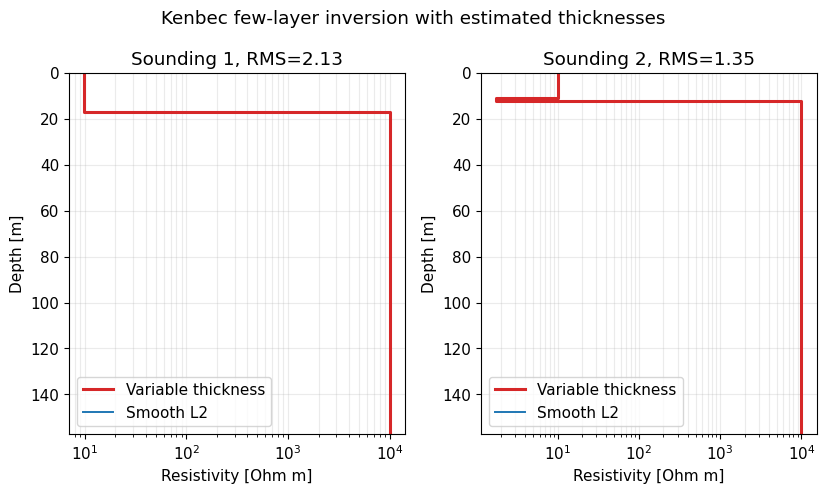

In [25]:
few_layer_station_indices = transect_station_indices.copy()

if FEW_LAYER_MAX_STATIONS is not None:

    few_layer_station_indices = few_layer_station_indices[:max(0, int(FEW_LAYER_MAX_STATIONS))]



few_layer_results = []

if RUN_FEW_LAYER_INVERSION:

    started = time.perf_counter()

    for position, station_index in enumerate(few_layer_station_indices):

        if (

            position < kenbec_smooth_rho.shape[0]

            and np.all(np.isfinite(kenbec_smooth_rho[position]))

        ):

            smooth_resistivities = kenbec_smooth_rho[position]

        else:

            smooth_resistivities = np.full(n_layers, 100.0)



        result = invert_few_layer_station(int(station_index), smooth_resistivities)

        few_layer_results.append(result)

        print(

            f"Few-layer sounding {position + 1}/{few_layer_station_indices.size}: "

            f"RMS={result['rms']:.3f}, rho={np.round(result['resistivities'], 1)}, "

            f"boundaries={np.round(result['boundary_depths'], 1)} m, "

            f"nfev={result['nfev']}, success={result['success']}"

        )



    elapsed_few_layer = time.perf_counter() - started

    print(f"Completed few-layer inversions in {elapsed_few_layer / 60.0:.1f} min.")

else:

    print("Set RUN_FEW_LAYER_INVERSION = True to run the few-layer inversions.")





if few_layer_results:

    figure, axes = plt.subplots(

        1,

        len(few_layer_results),

        figsize=(4.2 * len(few_layer_results), 5),

        squeeze=False,

    )

    plot_bottom = max(

        interface_depths[-1] + thicknesses[-1],

        max(result["boundary_depths"][-1] for result in few_layer_results) * 1.25,

    )

    for position, (axis, result) in enumerate(zip(axes[0], few_layer_results)):

        few_x, few_z = step_coordinates(

            result["resistivities"],

            result["thicknesses"],

            plot_bottom=plot_bottom,

        )

        axis.plot(

            few_x,

            few_z,

            color="tab:red",

            linewidth=2.2,

            label="Variable thickness",

        )

        if position < kenbec_smooth_rho.shape[0]:

            smooth_x, smooth_z = step_coordinates(

                kenbec_smooth_rho[position],

                thicknesses,

                plot_bottom=plot_bottom,

            )

            axis.plot(

                smooth_x,

                smooth_z,

                color="tab:blue",

                linewidth=1.4,

                label="Smooth L2",

            )

        axis.set(

            xscale="log",

            xlabel="Resistivity [Ohm m]",

            ylabel="Depth [m]",

            ylim=(plot_bottom, 0.0),

            title=f"Sounding {position + 1}, RMS={result['rms']:.2f}",

        )

        axis.grid(True, which="both", alpha=0.25)

        axis.legend()

    figure.suptitle("Kenbec few-layer inversion with estimated thicknesses")

    figure.tight_layout()

    plt.show()